LyriValence_Song_Mood_Prediction

In [1]:
!pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn nltk joblib wordcloud

1. IMPORT LIBRARIES

In [2]:
import os
import re
import string
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import kagglehub

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

2. DOWNLOAD NLTK RESOURCES

In [3]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

3. DOWNLOAD DATASET DIRECTLY FROM KAGGLE

In [4]:
print("Downloading dataset...")

dataset_path = kagglehub.dataset_download(
    "edenbd/150k-lyrics-labeled-with-spotify-valence"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 53.7M/53.7M [00:00<00:00, 82.6MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/edenbd/150k-lyrics-labeled-with-spotify-valence/versions/1


4. FIND CSV FILE

In [5]:
csv_file = None

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".csv"):

            if "labeled_lyrics_cleaned" in file:

                csv_file = os.path.join(
                    root,
                    file
                )

                break

    if csv_file:
        break


if csv_file is None:

    raise FileNotFoundError(
        "labeled_lyrics_cleaned.csv was not found."
    )


print("CSV file:")
print(csv_file)

CSV file:
/root/.cache/kagglehub/datasets/edenbd/150k-lyrics-labeled-with-spotify-valence/versions/1/labeled_lyrics_cleaned.csv


5. LOAD DATA

In [6]:
df = pd.read_csv(csv_file)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())


Dataset Shape:
(158353, 5)

Columns:
['Unnamed: 0', 'artist', 'seq', 'song', 'label']


,Unnamed: 0,artist,seq,song,label
0,0,Elijah Blake,"No, no\r\nI ain't ever trapped out the bando\r...",Everyday,0.626
1,1,Elijah Blake,"The drinks go down and smoke goes up, I feel m...",Live Till We Die,0.630
2,2,Elijah Blake,She don't live on planet Earth no more\r\nShe ...,The Otherside,0.240
3,3,Elijah Blake,"Trippin' off that Grigio, mobbin', lights low\...",Pinot,0.536
4,4,Elijah Blake,"I see a midnight panther, so gallant and so br...",Shadows & Diamonds,0.371


6. RENAME COLUMNS

In [7]:
rename_dict = {}

if "label" in df.columns:
    rename_dict["label"] = "valence"

if "seq" in df.columns:
    rename_dict["seq"] = "lyrics"

df.rename(
    columns=rename_dict,
    inplace=True
)

print("\nColumns after renaming:")
print(df.columns.tolist())


Columns after renaming:
['Unnamed: 0', 'artist', 'lyrics', 'song', 'valence']


7. SELECT REQUIRED COLUMNS

In [8]:
required_columns = [
    "artist",
    "lyrics",
    "song",
    "valence"
]

available_columns = [
    col
    for col in required_columns
    if col in df.columns
]

df = df[
    available_columns
].copy()

print("\nSelected columns:")
print(df.columns.tolist())


Selected columns:
['artist', 'lyrics', 'song', 'valence']


8. DATA QUALITY CHECK

In [9]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
artist     0
lyrics     0
song       2
valence    0
dtype: int64

Duplicate rows:
11


9. REMOVE MISSING VALUES

In [10]:
df = df.dropna(
    subset=[
        "lyrics",
        "valence"
    ]
).reset_index(drop=True)


10. REMOVE DUPLICATES

In [11]:
df = df.drop_duplicates(
    subset=[
        "artist",
        "song",
        "lyrics"
    ]
).reset_index(drop=True)


print("\nDataset after cleaning:")
print(df.shape)


Dataset after cleaning:
(158342, 4)


11. CLEAN LYRICS

In [12]:
def clean_lyrics(text):

    text = str(text)

    # New lines
    text = re.sub(
        r"\n",
        " ",
        text
    )

    # Carriage returns
    text = re.sub(
        r"\r",
        " ",
        text
    )

    # Lowercase
    text = text.lower()

    # URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["clean_lyrics"] = (
    df["lyrics"]
    .apply(clean_lyrics)
)


12. WORD COUNT

In [13]:
df["word_count"] = (
    df["clean_lyrics"]
    .str.split()
    .str.len()
)

print(
    "\nWord count statistics:"
)

print(
    df["word_count"].describe()
)



Word count statistics:
count    158342.000000
mean        219.142950
std         133.339491
min           0.000000
25%         135.000000
50%         190.000000
75%         263.000000
max        2836.000000
Name: word_count, dtype: float64


13. REMOVE VERY SHORT LYRICS

In [14]:
df = df[
    df["word_count"] >= 10
].reset_index(drop=True)

print(
    "\nDataset after removing short lyrics:"
)

print(df.shape)


Dataset after removing short lyrics:
(157676, 6)


14. VALENCE EDA

In [15]:
print(
    "\nValence statistics:"
)

print(
    df["valence"].describe()
)


Valence statistics:
count    157676.000000
mean          0.491437
std           0.249329
min           0.000000
25%           0.286000
50%           0.484000
75%           0.691000
max           0.998000
Name: valence, dtype: float64


15. VALENCE DISTRIBUTION

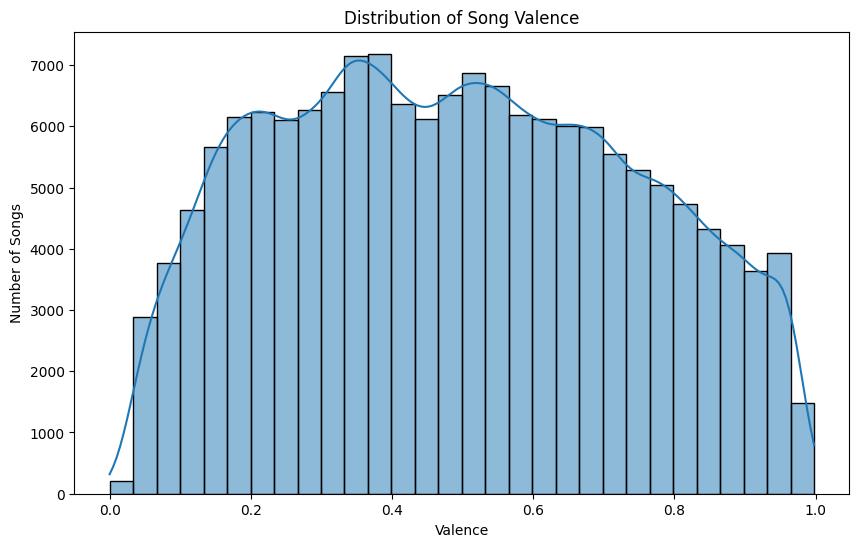

In [16]:
plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    df["valence"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Song Valence"
)

plt.xlabel(
    "Valence"
)

plt.ylabel(
    "Number of Songs"
)

plt.show()

16. VALENCE CATEGORY

In [17]:
def valence_category(value):

    if value < 0.33:
        return "Low"

    elif value < 0.66:
        return "Medium"

    else:
        return "High"


df["valence_category"] = (
    df["valence"]
    .apply(valence_category)
)

17. VALENCE CATEGORY PLOT

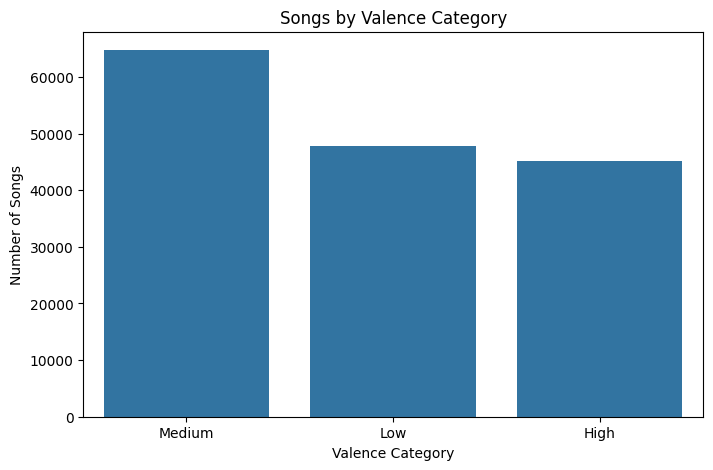

In [18]:
plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    data=df,
    x="valence_category"
)

plt.title(
    "Songs by Valence Category"
)

plt.xlabel(
    "Valence Category"
)

plt.ylabel(
    "Number of Songs"
)

plt.show()

18. LYRICS LENGTH VS VALENCE

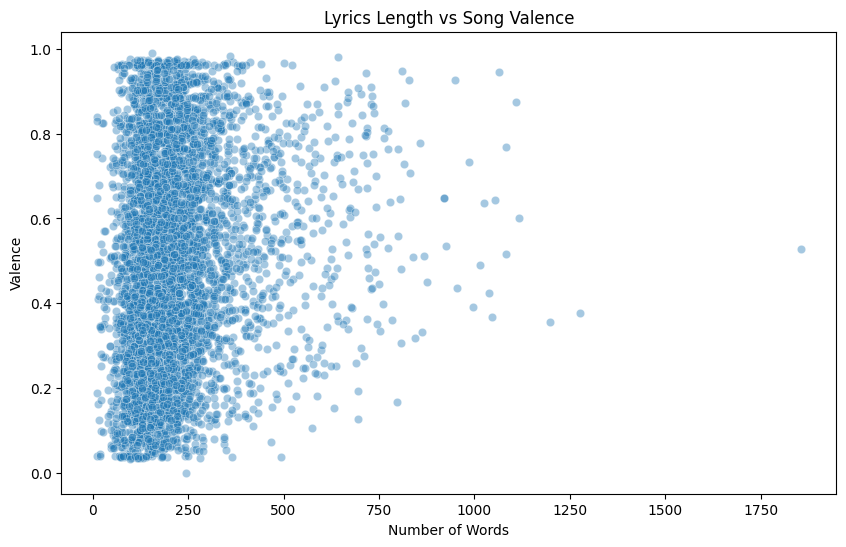

In [19]:
plot_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(
    figsize=(10, 6)
)

sns.scatterplot(
    data=plot_df,
    x="word_count",
    y="valence",
    alpha=0.4
)

plt.title(
    "Lyrics Length vs Song Valence"
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Valence"
)

plt.show()

19. STOPWORDS AND LEMMATIZATION

In [20]:
stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()


def preprocess_text(text):

    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)


df["processed_lyrics"] = (
    df["clean_lyrics"]
    .apply(preprocess_text)
)

20. CREATE MODEL DATASET

In [21]:
# Use 50,000 songs for faster training.
# Change this to len(df) if you want to use all data.

SAMPLE_SIZE = 50000

if len(df) > SAMPLE_SIZE:

    model_df = df.sample(
        SAMPLE_SIZE,
        random_state=42
    ).reset_index(drop=True)

else:

    model_df = df.copy()


print(
    "\nModel dataset:"
)

print(
    model_df.shape
)


Model dataset:
(50000, 8)


21. TF-IDF

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)


X = tfidf.fit_transform(
    model_df["processed_lyrics"]
)

y = model_df["valence"]


print(
    "\nTF-IDF Feature Matrix:"
)

print(
    X.shape
)

22. TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    "\nTraining data:",
    X_train.shape
)

print(
    "Testing data:",
    X_test.shape
)

23. EVALUATION FUNCTION

In [ ]:
def evaluate_model(
    name,
    y_true,
    predictions
):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    print("\n" + "=" * 50)

    print(name)

    print("=" * 50)

    print(
        f"MAE  : {mae:.4f}"
    )

    print(
        f"RMSE : {rmse:.4f}"
    )

    print(
        f"R²   : {r2:.4f}"
    )

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

24. RIDGE REGRESSION

In [ ]:
print("\nTraining Ridge Regression...")

ridge_model = Ridge(
    alpha=10.0
)

ridge_model.fit(
    X_train,
    y_train
)

ridge_pred = ridge_model.predict(
    X_test
)

ridge_result = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_pred
)


25. LINEAR REGRESSION

In [ ]:
print("\nTraining Linear Regression...")

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

linear_result = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)

26. RANDOM FOREST

In [ ]:
print("\nTraining Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)


Training Random Forest...


27. MODEL COMPARISON

In [ ]:
results = pd.DataFrame([
    ridge_result,
    linear_result,
    rf_result
])

results = results.sort_values(
    "RMSE"
).reset_index(drop=True)

print("\nFINAL MODEL COMPARISON")

display(results)

28. RMSE COMPARISON

In [ ]:
plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title(
    "Model Comparison - RMSE"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()

29. R2 COMPARISON

In [ ]:
plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title(
    "Model Comparison - R²"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()

30. SELECT BEST MODEL

In [ ]:
best_model_name = results.iloc[0]["Model"]

print(
    "\nBest Model:",
    best_model_name
)


if best_model_name == "Ridge Regression":

    best_model = ridge_model
    best_predictions = ridge_pred

elif best_model_name == "Linear Regression":

    best_model = linear_model
    best_predictions = linear_pred

else:

    best_model = rf_model
    best_predictions = rf_pred

31. ACTUAL VS PREDICTED

In [ ]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Actual Valence"
)

plt.ylabel(
    "Predicted Valence"
)

plt.title(
    f"Actual vs Predicted Valence - {best_model_name}"
)

plt.show()

32. ERROR DISTRIBUTION

In [ ]:
errors = (
    y_test - best_predictions
)

plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    errors,
    bins=30,
    kde=True
)

plt.title(
    "Prediction Error Distribution"
)

plt.xlabel(
    "Prediction Error"
)

plt.show()

33. TOP WORDS FOR RIDGE MODEL

In [ ]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefficients = ridge_model.coef_

top_positive = np.argsort(
    coefficients
)[-20:][::-1]

top_negative = np.argsort(
    coefficients
)[:20]


positive_words = pd.DataFrame({
    "Word": feature_names[top_positive],
    "Coefficient": coefficients[top_positive]
})

negative_words = pd.DataFrame({
    "Word": feature_names[top_negative],
    "Coefficient": coefficients[top_negative]
})


print(
    "\nWords associated with higher valence:"
)

display(
    positive_words
)


print(
    "\nWords associated with lower valence:"
)

display(
    negative_words
)

34. PREDICTION FUNCTION

In [ ]:
def predict_song_valence(lyrics):

    cleaned = clean_lyrics(
        lyrics
    )

    processed = preprocess_text(
        cleaned
    )

    features = tfidf.transform(
        [processed]
    )

    prediction = best_model.predict(
        features
    )[0]

    prediction = np.clip(
        prediction,
        0,
        1
    )

    return prediction

35. MOOD FUNCTION

In [ ]:
def get_mood(score):

    if score < 0.33:

        return "Sad / Negative"

    elif score < 0.66:

        return "Neutral / Mixed"

    else:

        return "Happy / Positive"

36. TEST NEW SONG

In [ ]:
new_song_lyrics = """
I feel the sunshine on my face
Dancing through the night
Everything is beautiful
And everything feels right
We sing together
And enjoy this wonderful day
"""


prediction = predict_song_valence(
    new_song_lyrics
)

print(
    "\nPredicted Valence:",
    round(prediction, 4)
)

print(
    "Predicted Mood:",
    get_mood(prediction)
)

37. SAVE BEST MODEL

In [ ]:
joblib.dump(
    best_model,
    "best_lyrics_valence_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print(
    "\nModel saved successfully!"
)


38. SAVE RESULTS

In [ ]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

model_df.to_csv(
    "processed_lyrics_valence.csv",
    index=False
)

positive_words.to_csv(
    "positive_valence_words.csv",
    index=False
)

negative_words.to_csv(
    "negative_valence_words.csv",
    index=False
)

39. FINAL SUMMARY

In [ ]:
print("\n")
print("=" * 60)
print("CUETESSA SONG VALENCE PREDICTION - FINAL SUMMARY")
print("=" * 60)

print(
    f"Dataset size       : {len(df):,}"
)

print(
    f"Training samples    : {len(X_train):,}"
)

print(
    f"Testing samples     : {len(X_test):,}"
)

print(
    f"TF-IDF features     : {X.shape[1]:,}"
)

print(
    f"Best model          : {best_model_name}"
)

best_row = results.iloc[0]

print(
    f"Best MAE            : {best_row['MAE']:.4f}"
)

print(
    f"Best RMSE           : {best_row['RMSE']:.4f}"
)

print(
    f"Best R²             : {best_row['R2']:.4f}"
)

print("=" * 60)